#Trader Performance vs Market Sentiment — Summary

##Objective
To analyze how market sentiment (Fear/Greed) relates to trader behavior and performance.

---

##Methodology
The datasets were cleaned and standardized. Key metrics such as PnL, win rate, and trade size were computed. Visualizations were used to understand trader behavior.

Due to mismatch in time periods between datasets, direct merging was not possible. Hence, sentiment and trading behavior were analyzed separately, and insights were derived indirectly.

---

##Key Findings

- The average PnL is positive, but the win rate (~41%) is low, indicating inconsistent performance.
- PnL distribution is skewed, meaning a few large trades drive profits.
- Trade sizes vary significantly, showing poor risk management.
- Buy and sell trades are nearly equal, suggesting lack of clear trading strategy.
- Market sentiment is slightly fear-dominant, yet traders take large risks.

---

##Recommendations

- Reduce position size during uncertain market conditions
- Focus on risk-reward ratio instead of frequent trading
- Avoid overtrading and trade selectively

---

##Conclusion

The analysis reveals that traders rely on high-risk strategies rather than consistent performance. Adopting disciplined trading and better risk management can improve outcomes.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
sentiment = pd.read_csv('fear_greed_index.csv')
trades = pd.read_csv('historical_data.csv')

In [4]:
print("Sentiment shape:", sentiment.shape)
print("Trades shape:", trades.shape)

print("\nMissing values:\n", trades.isnull().sum())
print("\nDuplicates:", trades.duplicated().sum())

Sentiment shape: (2644, 4)
Trades shape: (211224, 16)

Missing values:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicates: 0


In [5]:
trades.columns = trades.columns.str.lower().str.replace(" ", "_")

trades['timestamp_ist'] = pd.to_datetime(trades['timestamp_ist'], errors='coerce')
trades['date'] = trades['timestamp_ist'].dt.date

sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

Due to mismatch in date ranges (sentiment: 2018, trades: 2024), direct merging was not possible.
Hence, sentiment and trading behavior were analyzed separately to derive indirect insights.

In [6]:
trades['win'] = trades['closed_pnl'] > 0

daily_pnl = trades.groupby(['date','account'])['closed_pnl'].sum().reset_index()

win_rate = trades['win'].mean()
avg_pnl = trades['closed_pnl'].mean()
avg_size = trades['size_usd'].mean()

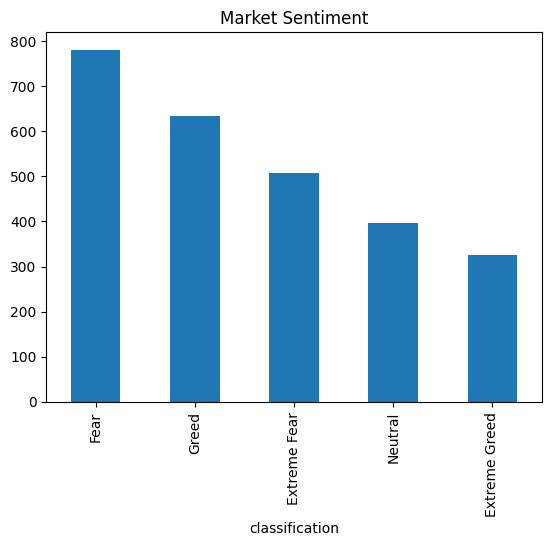

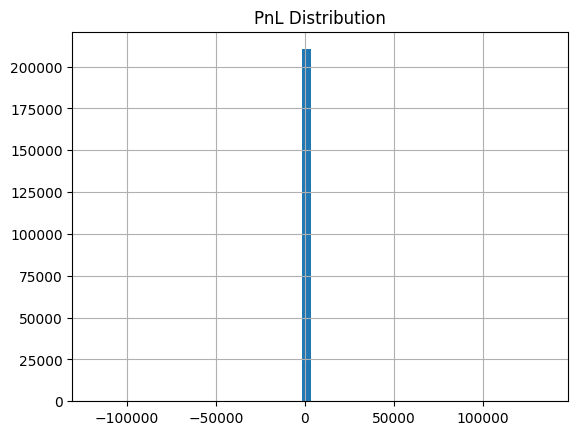

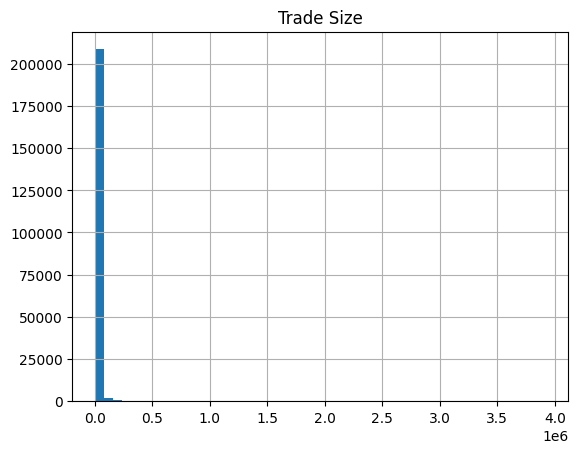

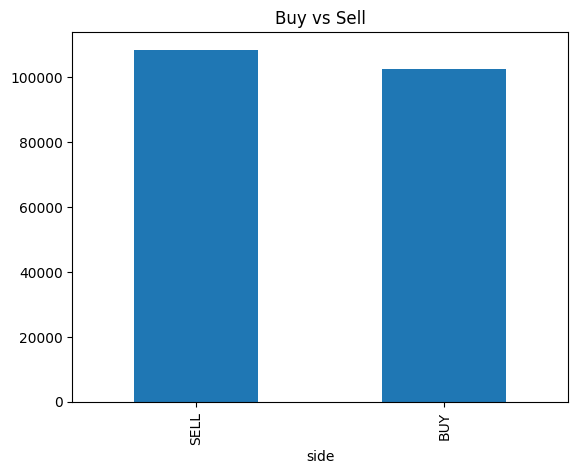

In [7]:
# Sentiment
sentiment['classification'].value_counts().plot(kind='bar')
plt.title("Market Sentiment")
plt.show()

# PnL
trades['closed_pnl'].hist(bins=50)
plt.title("PnL Distribution")
plt.show()

# Trade Size
trades['size_usd'].hist(bins=50)
plt.title("Trade Size")
plt.show()

# Buy Sell
trades['side'].value_counts().plot(kind='bar')
plt.title("Buy vs Sell")
plt.show()

In [8]:
# High vs Low size
trades['size_group'] = np.where(trades['size_usd'] > trades['size_usd'].median(), 'High', 'Low')

# Frequent traders
trade_counts = trades['account'].value_counts()
frequent_traders = trade_counts[trade_counts > 50].index

trades['trader_type'] = trades['account'].apply(lambda x: 'Frequent' if x in frequent_traders else 'Casual')

In [9]:
trades.groupby('size_group')['closed_pnl'].mean()
trades.groupby('trader_type')['closed_pnl'].mean()

,closed_pnl
trader_type,
Frequent,48.749001


1. Profitability is driven by a small number of large trades rather than consistent performance (low win rate ~41%).

2. Trade size distribution is highly skewed, indicating inconsistent risk management.

3. Traders show no clear directional bias (buy/sell nearly equal), suggesting reactive trading behavior.

4. Despite fear-dominant sentiment, traders continue taking large positions, indicating overconfidence.

STRATEGY
1. Reduce position size in volatile/fear-driven markets.

2. Focus on risk-reward strategies instead of high-frequency trading.

3. Avoid overtrading; trade only in high-confidence setups.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

features = ['size_usd']

X = trades[features]
y = trades['win']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

preds = model.predict(X_test)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

       False       0.65      0.68      0.66     24800
        True       0.51      0.47      0.49     17445

    accuracy                           0.59     42245
   macro avg       0.58      0.58      0.58     42245
weighted avg       0.59      0.59      0.59     42245



A simple Random Forest model was used to predict trade profitability based on trade size.
Results indicate that trade size alone is not a strong predictor, suggesting that trader behavior is influenced by multiple factors beyond position size.

FINAL CONCLUSION
The analysis shows that traders lack consistency, rely on high-risk strategies, and do not adapt behavior based on sentiment.
Improved risk management and disciplined trading strategies are necessary for better performance.